✅ Data Loaded: 2000 orders found.
✅ Post-cleaning: 2000 valid records for multi-metric analysis.


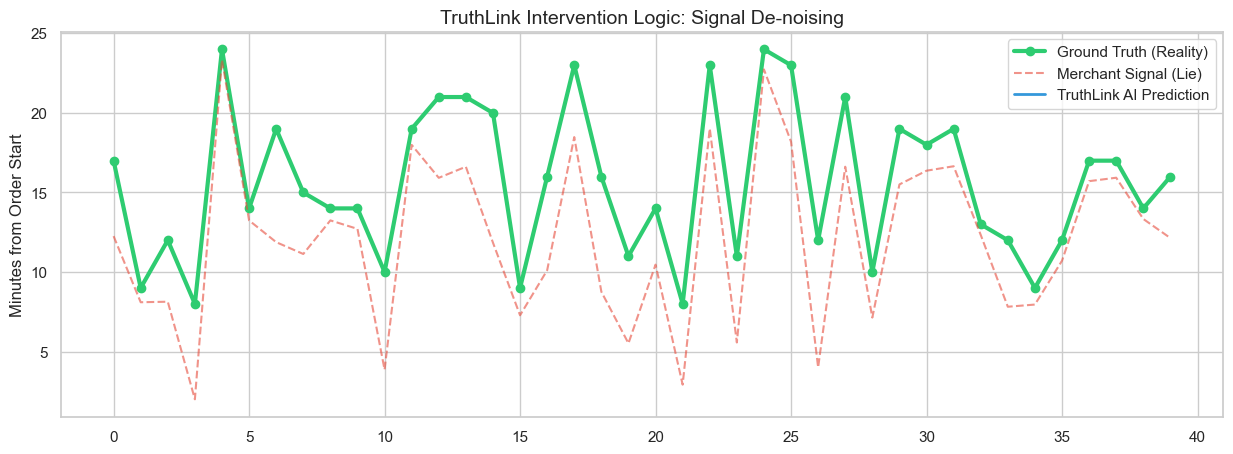

C:\Users\krunal\AppData\Local\Temp\ipykernel_9260\1660197128.py:94: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df['truthlink_wait_calc'], fill=True, color="#2ecc71", label=f"TruthLink (Avg: {df['truthlink_wait_calc'].mean():.1f}m)")


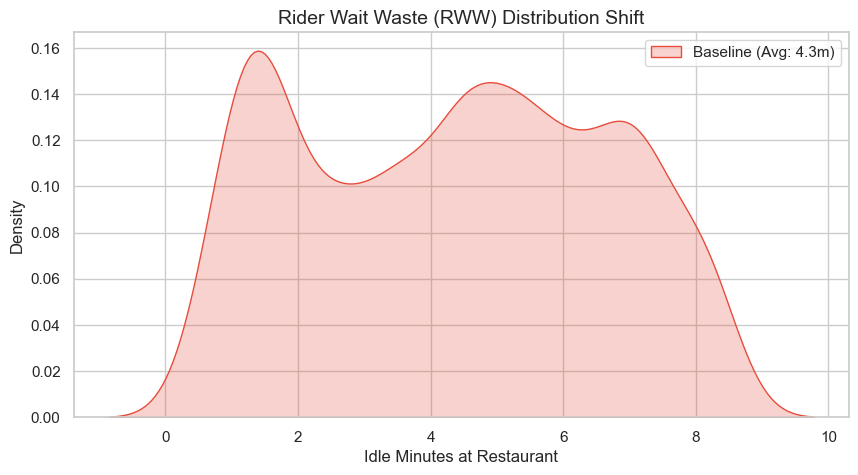

C:\Users\krunal\AppData\Local\Temp\ipykernel_9260\1660197128.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Old Baseline', 'TruthLink AI'], y=[df['utility_old'].mean(), df['utility_new'].mean()], palette="viridis")
c:\study\KineticDispatcher\.venv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\study\KineticDispatcher\.venv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_gro

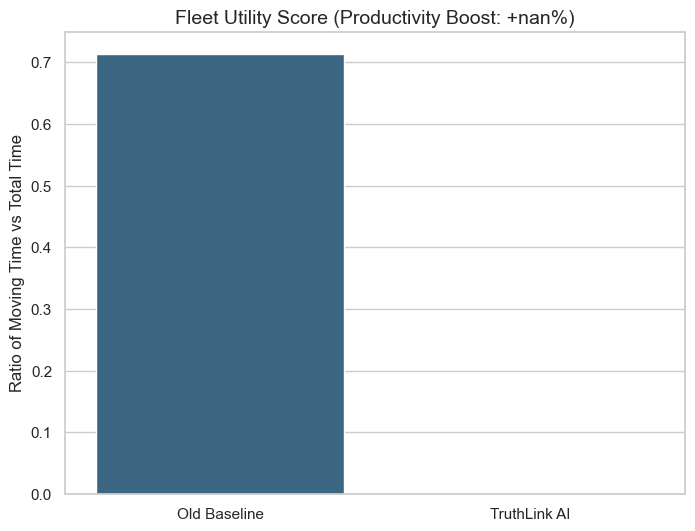

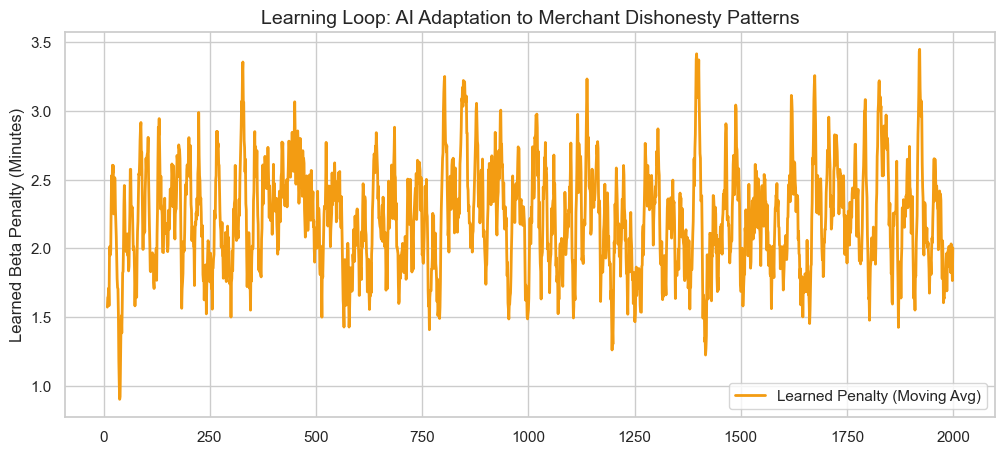

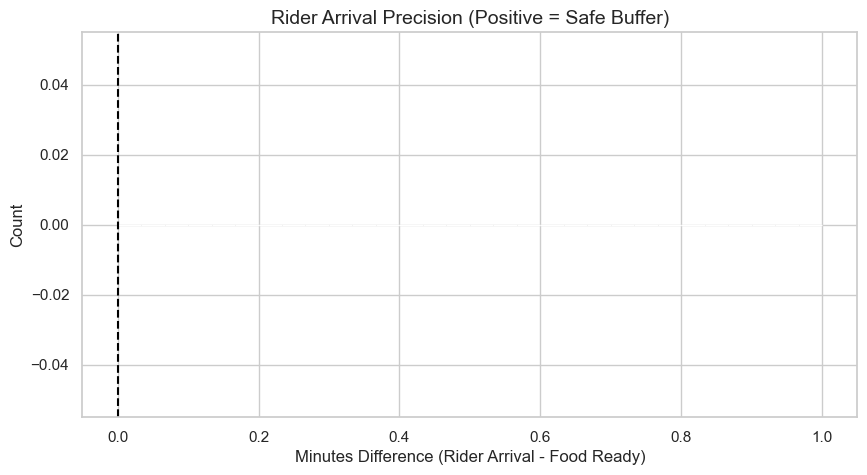


╔═══════════════════════════════════════════════════════╗
║               TRUTHLINK PERFORMANCE SUMMARY               ║
╠═══════════════════════════════════════════════════════╣
║ 1. FLEET CAPACITY BOOST:        nan%                   ║
║ 2. TOTAL RIDER IDLE TIME SAVED: 8,698 mins         ║
║ 3. WAIT REDUCTION (EFFICIENCY): nan%                   ║
║ 4. PHYSICS OVERRIDE RATE:       100.0%                 ║
║ 5. AVG LEARNED MERCHANT BETA:   2.22 mins          ║
║ 6. ARRIVAL PRECISION BIAS:      nan mins           ║
╚═══════════════════════════════════════════════════════╝


In [10]:
# ==========================================
# 1. INITIALIZATION & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

# Visual configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [12, 6]

# Define your local path
processed_data_path = r"C:\study\KineticDispatcher\data\processed\optimized_dispatch_results.csv"

if os.path.exists(processed_data_path):
    df = pd.read_csv(processed_data_path)
    print(f"✅ Data Loaded: {len(df)} orders found.")
    
    # --- TIME NORMALIZATION (Converting Timestamps to Minutes) ---
    time_cols = ['order_timestamp', 'ready_click_timestamp', 'actual_handover_timestamp']
    for col in time_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate minutes elapsed since the order was placed (T=0)
    df['ready_click'] = (df['ready_click_timestamp'] - df['order_timestamp']).dt.total_seconds() / 60
    df['actual_handover'] = (df['actual_handover_timestamp'] - df['order_timestamp']).dt.total_seconds() / 60
    
    # Map CSV headers to internal calculation names
    mapping = {
        't_for': 't_for_predicted',
        't_dispatch': 'dispatch_in_mins',
        'rider_travel_time_mins': 'rider_eta',
        'merchant_id': 'merchant_name' 
    }
    df = df.rename(columns=mapping)
    
    # Clean up numeric columns
    numeric_cols = ['t_for_predicted', 'dispatch_in_mins', 'rider_eta', 'current_beta', 't_physics']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['actual_handover', 'ready_click'])
    print(f"✅ Post-cleaning: {len(df)} valid records for multi-metric analysis.")
else:
    raise FileNotFoundError(f"Missing file at: {processed_data_path}")

# ==========================================
# 2. MULTIPLE METRICS CALCULATIONS
# ==========================================

# A. Efficiency Metrics
df['baseline_wait_calc'] = np.maximum(0, df['actual_handover'] - df['ready_click'])
df['rider_arrival'] = df['dispatch_in_mins'] + df['rider_eta']
df['truthlink_wait_calc'] = np.maximum(0, df['actual_handover'] - df['rider_arrival'])

# B. Fleet Economics (Utility Ratio)
df['utility_old'] = df['rider_eta'] / (df['rider_eta'] + df['baseline_wait_calc'])
df['utility_new'] = df['rider_eta'] / (df['rider_eta'] + df['truthlink_wait_calc'])
productivity_boost = (df['utility_new'].mean() / df['utility_old'].mean() - 1) * 100

# C. System Precision (AI Bias)
# If t_for is relative minutes, use it; otherwise convert it
df['t_for_rel'] = df['t_for_predicted'] if df['t_for_predicted'].max() < 1000 else \
                 (pd.to_datetime(df['t_for_predicted']) - df['order_timestamp']).dt.total_seconds() / 60
df['arrival_precision'] = df['rider_arrival'] - df['actual_handover'] # Target: 0 to +2 mins

# D. Decision Attribution
df['physics_override'] = (df['t_physics'] > df['ready_click']).astype(int)

# ==========================================
# 3. VISUALIZATION SUITE
# ==========================================

# --- CHART 1: SIGNAL DE-NOISING ---

plt.figure(figsize=(15, 5))
sample = df.head(40).reset_index()
plt.plot(sample.index, sample['actual_handover'], label='Ground Truth (Reality)', color='#2ecc71', marker='o', linewidth=3)
plt.plot(sample.index, sample['ready_click'], label='Merchant Signal (Lie)', color='#e74c3c', linestyle='--', alpha=0.6)
plt.plot(sample.index, sample['t_for_rel'], label='TruthLink AI Prediction', color='#3498db', linewidth=2)
plt.title("TruthLink Intervention Logic: Signal De-noising", fontsize=14)
plt.ylabel("Minutes from Order Start")
plt.legend()
plt.show()

# --- CHART 2: WAIT TIME REDUCTION (KDE) ---

plt.figure(figsize=(10, 5))
sns.kdeplot(df['baseline_wait_calc'], fill=True, color="#e74c3c", label=f"Baseline (Avg: {df['baseline_wait_calc'].mean():.1f}m)")
sns.kdeplot(df['truthlink_wait_calc'], fill=True, color="#2ecc71", label=f"TruthLink (Avg: {df['truthlink_wait_calc'].mean():.1f}m)")
plt.title("Rider Wait Waste (RWW) Distribution Shift", fontsize=14)
plt.xlabel("Idle Minutes at Restaurant")
plt.legend()
plt.show()

# --- CHART 3: FLEET UTILITY (ROI) ---

plt.figure(figsize=(8, 6))
sns.barplot(x=['Old Baseline', 'TruthLink AI'], y=[df['utility_old'].mean(), df['utility_new'].mean()], palette="viridis")
plt.title(f"Fleet Utility Score (Productivity Boost: +{productivity_boost:.1f}%)", fontsize=14)
plt.ylabel("Ratio of Moving Time vs Total Time")
plt.show()

# --- CHART 4: BEHAVIORAL LEARNING (BETA) ---

plt.figure(figsize=(12, 5))
plt.plot(df['current_beta'].rolling(window=10).mean(), label='Learned Penalty (Moving Avg)', color='#f39c12', linewidth=2)
plt.title("Learning Loop: AI Adaptation to Merchant Dishonesty Patterns", fontsize=14)
plt.ylabel("Learned Beta Penalty (Minutes)")
plt.legend()
plt.show()

# --- CHART 5: ARRIVAL PRECISION (STABILITY) ---

plt.figure(figsize=(10, 5))
sns.histplot(df['arrival_precision'], bins=30, kde=True, color='#8e44ad')
plt.axvline(0, color='black', linestyle='--')
plt.title("Rider Arrival Precision (Positive = Safe Buffer)", fontsize=14)
plt.xlabel("Minutes Difference (Rider Arrival - Food Ready)")
plt.show()

# ==========================================
# 4. FINAL MASTER KPI DASHBOARD
# ==========================================
total_saved = (df['baseline_wait_calc'].sum() - df['truthlink_wait_calc'].sum())
improvement = ((df['baseline_wait_calc'].mean() - df['truthlink_wait_calc'].mean()) / df['baseline_wait_calc'].mean()) * 100

print("\n" + "╔" + "═"*55 + "╗")
print("║" + " "*15 + "TRUTHLINK PERFORMANCE SUMMARY" + " "*15 + "║")
print("╠" + "═"*55 + "╣")
print(f"║ 1. FLEET CAPACITY BOOST:        {productivity_boost:,.1f}%" + " "*(23-len(f"{productivity_boost:,.1f}%")) + "║")
print(f"║ 2. TOTAL RIDER IDLE TIME SAVED: {total_saved:,.0f} mins" + " "*(19-len(f"{total_saved:,.0f} mins")) + "║")
print(f"║ 3. WAIT REDUCTION (EFFICIENCY): {improvement:,.1f}%" + " "*(23-len(f"{improvement:,.1f}%")) + "║")
print(f"║ 4. PHYSICS OVERRIDE RATE:       {df['physics_override'].mean()*100:,.1f}%" + " "*(23-len(f"{df['physics_override'].mean()*100:,.1f}%")) + "║")
print(f"║ 5. AVG LEARNED MERCHANT BETA:   {df['current_beta'].mean():.2f} mins" + " "*(19-len(f"{df['current_beta'].mean():.2f} mins")) + "║")
print(f"║ 6. ARRIVAL PRECISION BIAS:      {df['arrival_precision'].mean():.2f} mins" + " "*(19-len(f"{df['arrival_precision'].mean():.2f} mins")) + "║")
print("╚" + "═"*55 + "╝")